In [1]:
import numpy as np
import scipy.stats as sts

In [132]:
def BIC_AIC(datos, distribucion, parametros):
    n=len(datos)
    k=len(parametros)
    log_verosimilitud=np.sum(np.log(distribucion.pdf(datos, *parametros)))
    AIC=-2*log_verosimilitud+2*k
    BIC=-2*log_verosimilitud+k*np.log(n)
    return AIC, BIC

In [134]:
def ajuste(datos, distribuciones):
    mejor_distribucion=None
    mejor_parametros=None
    mejor_BIC=np.inf
    
    for distribucion in distribuciones:
        parametros=distribucion.fit(datos)
        BIC, AIC=BIC_AIC(datos, distribucion, parametros)
    
    if BIC < mejor_BIC:
        mejor_distribucion=distribucion
        mejor_parametros=parametros
        mejor_BIC=BIC
    return mejor_distribucion, mejor_parametros, mejor_BIC

In [136]:
import seaborn as sns

diam=sns.load_dataset('diamonds')

In [138]:
diam.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [140]:
diam['cut'].unique

<bound method Series.unique of 0            Ideal
1          Premium
2             Good
3          Premium
4             Good
           ...    
53935        Ideal
53936         Good
53937    Very Good
53938      Premium
53939        Ideal
Name: cut, Length: 53940, dtype: category
Categories (5, object): ['Ideal', 'Premium', 'Very Good', 'Good', 'Fair']>

In [142]:
diam_premium=diam[diam['cut']=='Premium']

In [144]:
diam_premium.head()

,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
12,0.22,Premium,F,SI1,60.4,61.0,342,3.88,3.84,2.33
14,0.20,Premium,E,SI2,60.2,62.0,345,3.79,3.75,2.27
15,0.32,Premium,E,I1,60.9,58.0,345,4.38,4.42,2.68


In [146]:
premium_depth=diam_premium['depth']

In [148]:
from scipy.stats import norm, chi2, lognorm, gamma

distribuciones1=[norm, chi2, lognorm, gamma]
ajuste(premium_depth, distribuciones1)

(<scipy.stats._continuous_distns.gamma_gen at 0x117a95070>,
 (282.3539186018081, 41.48118212483145, 0.07004103126159339),
 43558.35348216354)

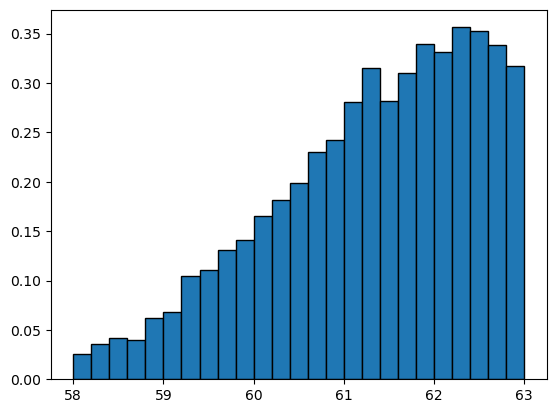

In [150]:
import matplotlib.pyplot as plt

plt.hist(premium_depth, density=True, bins=25, edgecolor='black')
plt.show()

In [152]:
premium_depth.describe()

count    13791.000000
mean        61.264673
std          1.158815
min         58.000000
25%         60.500000
50%         61.400000
75%         62.200000
max         63.000000
Name: depth, dtype: float64

In [156]:
#M2: Normal Truncada

from scipy.stats import truncnorm
mu=61.26
sigma=1.15
a=(58-mu)/sigma
b=(63-mu)/sigma
M2=truncnorm(a, b, 61.2, 1.15)

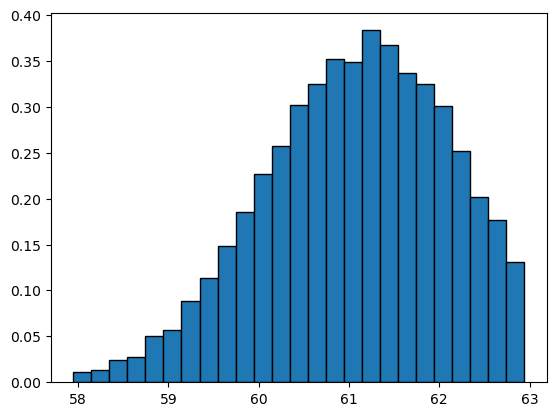

In [158]:
dataM2=M2.rvs(size=13791)
plt.hist(dataM1, density=True, bins =25, edgecolor='black')
plt.show()

In [160]:
parametros2=[a, b, mu, sigma]
BIC_AIC(premium_depth, truncnorm, parametros2)

(41286.07405894328, 41316.20114488118)

In [185]:
#M3: Beta Re-escalada
from scipy.stats import beta

S=premium_depth.max()-premium_depth.min()
eps=1e-6
Y=np.clip((premium_depth-58)/S, eps, 1-eps)
alpha, betta, loc, scale=beta.fit(Y, floc=0, fscale=1)

In [187]:
alpha, betta

(1.5405228224861287, 0.8161084273892708)

In [195]:
L3=np.sum(beta.logpdf(Y, alpha, betta)) - len(Y)*np.log(S)
k = 2
k*np.log(len(Y)) - 2*L3

40092.15590342189

In [199]:
def sim_beta_re(L):
    Z=beta.rvs(alpha, betta, size=L)
    return Z*S+58

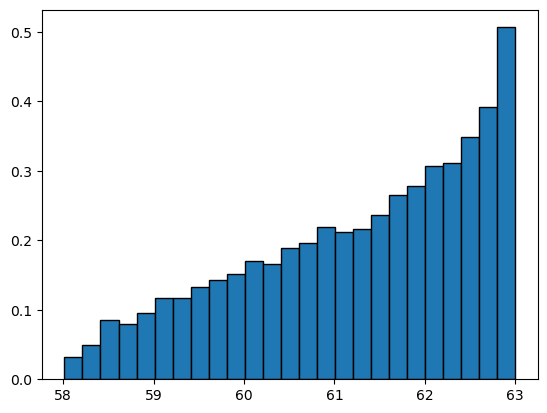

In [209]:
data3=sim_beta_re(len(premium_depth))

plt.hist(data3, density=True, bins=25, edgecolor='black')
plt.show()